# Análise da Cotação Histórica USD/BRL (2010-2019)

**Aluno:** Reginaldo Alves Domingos Junior  
**RGM:** 44789432  
**Instituição:** Cruzeiro do Sul  
**Curso:** Sistemas de Informação

## Objetivo
Explorar a série histórica diária da cotação do dólar comercial em reais (USD/BRL) entre 2010 e 2019, aplicando três técnicas distintas de visualização — cada uma adequada a uma pergunta de negócio diferente:

1. **Linha temporal** → *Como a cotação evoluiu ao longo do tempo?* (tendência)
2. **Histograma** → *Como os valores se distribuem?* (frequência)
3. **Boxplot por ano** → *Como a cotação se comporta dentro de cada ano?* (dispersão e outliers entre grupos)

## 1. Importação das bibliotecas e carga do dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Carrega o CSV — separador padrão (vírgula), formato de data dd.mm.yyyy
df = pd.read_csv('USD_BRL_hist.csv')
df['Data'] = pd.to_datetime(df['Data'], format='%d.%m.%Y')

# Ordena cronologicamente (o arquivo vem em ordem decrescente)
df = df.sort_values('Data').reset_index(drop=True)

# Coluna auxiliar de ano (útil para o boxplot agrupado)
df['Ano'] = df['Data'].dt.year

print(f'Registros: {len(df)}')
print(f'Período: {df["Data"].min().date()} a {df["Data"].max().date()}')
df.head()

Matplotlib is building the font cache; this may take a moment.


Registros: 2608
Período: 2010-01-01 a 2019-12-31


,Data,USD_BRL,Ano
0,2010-01-01,1.7430,2010
1,2010-01-04,1.7212,2010
2,2010-01-05,1.7310,2010
3,2010-01-06,1.7325,2010
4,2010-01-07,1.7465,2010


## 2. Estatísticas descritivas

In [2]:
df['USD_BRL'].describe()

count    2608.000000
mean        2.751703
std         0.839616
min         1.538300
25%         1.985350
50%         2.653100
75%         3.477100
max         4.263800
Name: USD_BRL, dtype: float64

## 3. Plot 1 — Série temporal (linha)

**Por que linha?** Para dados temporais com observações contínuas no tempo, o gráfico de linha é a escolha canônica: revela tendência, sazonalidade e quebras estruturais. Aqui fica nítida a forte desvalorização do real a partir de 2014/2015.

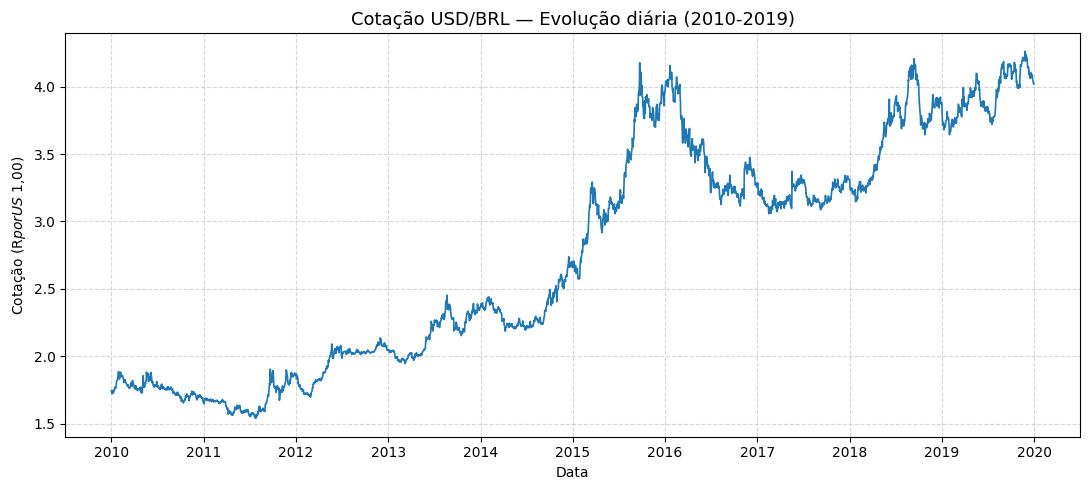

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df['Data'], df['USD_BRL'], color='#1f77b4', linewidth=1.2)
ax.set_title('Cotação USD/BRL — Evolução diária (2010-2019)', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Cotação (R$ por US$ 1,00)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot1_linha.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Plot 2 — Histograma (distribuição de frequências)

**Por que histograma?** Tira o tempo da equação e responde "em quais faixas de valor o dólar passou mais tempo?". É a visualização adequada para uma variável contínua quando o interesse é a distribuição, não a ordem temporal. A bimodalidade reflete os dois regimes da década: pré-2014 (~R$ 1,60–2,40) e pós-2014 (~R$ 3,00–4,20).

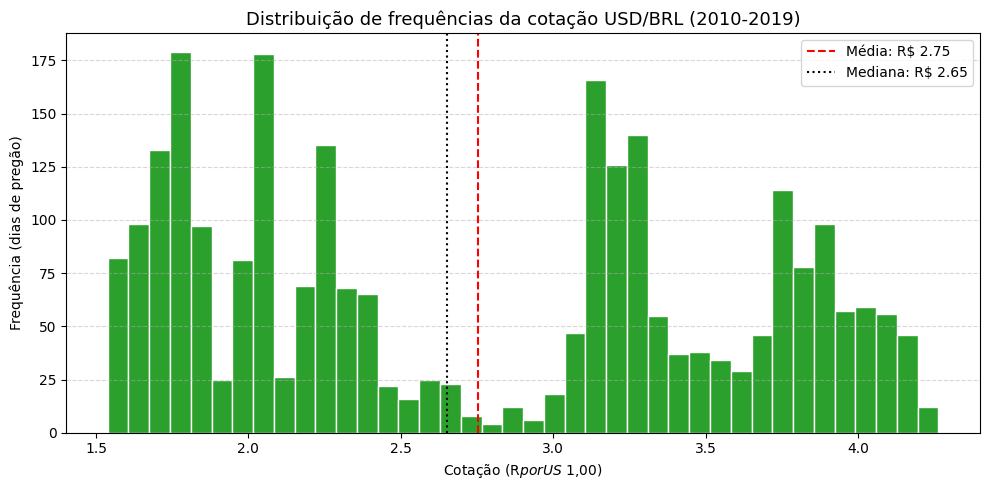

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['USD_BRL'], bins=40, color='#2ca02c', edgecolor='white')
ax.axvline(df['USD_BRL'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Média: R$ {df["USD_BRL"].mean():.2f}')
ax.axvline(df['USD_BRL'].median(), color='black', linestyle=':', linewidth=1.5,
           label=f'Mediana: R$ {df["USD_BRL"].median():.2f}')
ax.set_title('Distribuição de frequências da cotação USD/BRL (2010-2019)', fontsize=13)
ax.set_xlabel('Cotação (R$ por US$ 1,00)')
ax.set_ylabel('Frequência (dias de pregão)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.savefig('plot2_histograma.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Plot 3 — Boxplot por ano (comparação entre grupos)

**Por que boxplot agrupado?** Para comparar a dispersão de uma variável contínua entre várias categorias (anos), o boxplot é mais informativo que barras ou linhas: mostra mediana, intervalo interquartil e outliers de cada ano simultaneamente. Permite ver, por exemplo, que 2015 teve a maior volatilidade interna da década.

C:\Users\Junim e Rafa\AppData\Local\Temp\ipykernel_17724\557646148.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados_por_ano, labels=anos, patch_artist=True,


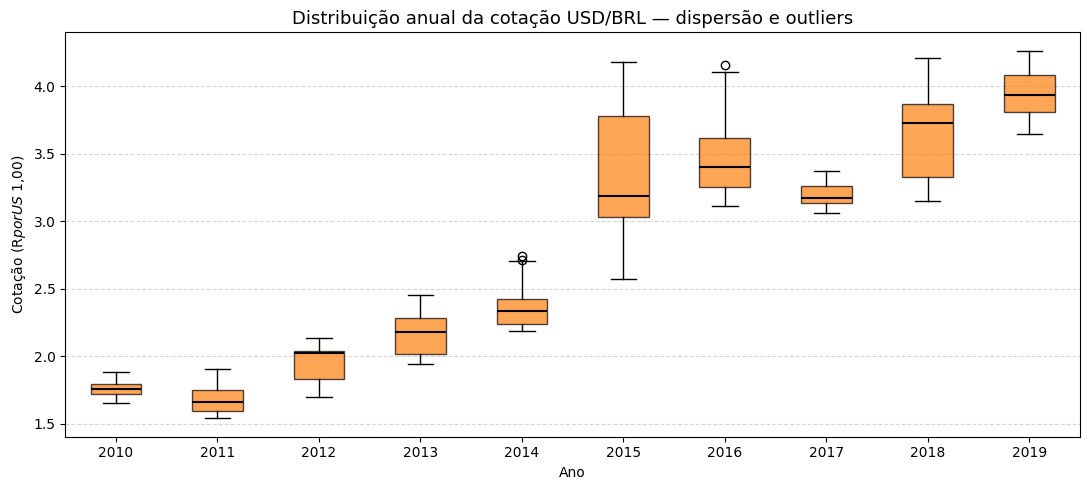

In [5]:
anos = sorted(df['Ano'].unique())
dados_por_ano = [df.loc[df['Ano'] == a, 'USD_BRL'].values for a in anos]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(dados_por_ano, labels=anos, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5))
for patch in bp['boxes']:
    patch.set_facecolor('#ff7f0e')
    patch.set_alpha(0.7)
ax.set_title('Distribuição anual da cotação USD/BRL — dispersão e outliers', fontsize=13)
ax.set_xlabel('Ano')
ax.set_ylabel('Cotação (R$ por US$ 1,00)')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.savefig('plot3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusão

Os três gráficos respondem perguntas diferentes sobre o mesmo dataset, ilustrando como a escolha da visualização depende da natureza da pergunta:

- A **linha** evidencia a tendência de longo prazo e o ponto de inflexão em 2014.
- O **histograma** revela uma distribuição bimodal, reflexo dos dois regimes cambiais da década.
- O **boxplot por ano** decompõe o comportamento por período, destacando 2015 como o ano de maior volatilidade interna.

Aplicar a visualização adequada à natureza dos dados é o que transforma um conjunto bruto em informação acionável.